# 특성공학과 규제

다항회귀 (polynomial regression) 로 농어의 길이에 대해 무게를 예측하였지만, 테스트 세트의 점수가 더 높은것이 찜찜하다. (언더피팅 의심) 제곱보다 더 고차항의 특성을 추가로 넣어야 할 것 같은데 몇 차까지 넣어야 하는지도 애매하고 수동으로 넣기도 힘들다. 어떻게 하면 개선할 수 있을까?

3.2절에서는 길이라는 하나의 특성을 1차원, 2차원 총 2개의 특성으로 다항 회귀모델 (polynomial regression)을 만들었다. 3.3장에서는 첫 문단의 문제를 해결하고자, 길이라는 하나의 특성으로 만드는 선형/다항 회귀를 넘어서서 다수의 특성으로 만드는 **다중 회귀모델 (multiple regression)**을 만든다.

이번 예제에서는 농어의 길이라는 특성 외에도 높이, 두께를 사용한다. 또, 3개의 특성을 각각 제곱한 것을 학습할 특성에 추가하고, 길이 x 높이 처럼 각 특성을 곱한 새로운 특성도 학습에 사용한다.

이렇게 기존의 특성을 사용해 길이x높이 같은 새로운 특성을 뽑아내는 작업을 **특성 공학 (feature engineering)** 이라고 한다.

**우리가 직접 제곱하고 특성끼리 곱해서 새로운 특성을 추가할 수도 있지만, 사이킷런에서 제공하는 편리한 도구를 사용할 수도 있다.**

In [1]:
# 데이터 준비
# 이전과 달리 농어의 특성이 3개로 늘어났기 때문에 데이터를 복사해 붙여넣는 것도 번거롭다.
# 인터넷에서 데이터를 바로 다운로드해서 사용하려면 판다스를 사용하자.

# 판다스(pandas)는 유명한 데이터 분석 라이브러리이다.
# 데이터프레임(dataframe)은 판다스의 핵심 데이터 구조이다.
# 넘파이 배열과 비슷하게 다차원 배열을 다룰 수 있지만, 훨씬 더 많은 기능을 제공한다. 또 데이터프레임은 넘파이 배열로 쉽게 바꿀 수 있다.

# 판다스를 이용해 농어 데이터를 인터넷에서 내려받아 데이터프레임에 저장해보자.
# 그 다음 넘파이 배열로 변환해서 선형 회귀모델을 훈련해보자.
# 판다스 데이터프레임을 만들기 위해서 많이 사용하는 csv형식의 파일을 사용하자.

import pandas as pd

df = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full = df.to_numpy()
print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [2]:
import numpy as np

# 타깃 데이터
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

# 훈련세트와 테스트세트로 나눈다.
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)

# 사이킷런의 변환기

사이킷런은 특성을 만들거나 전처리하기 위한 다양한 클래스를 제공한다. 사이킷런에서는 이런 클래스를 **변환기(transformer)**라고 부른다. **사이킷런의 모델 클래스에 일관된 fit(), score(), predict() 메서드가 있는 것처럼 변환기 클래스는 모두 fit(), transform() 메서드를 제공한다.**

우리가 사용할 변환기는 **PolynomialFeatures 클래스**이다.
```
from sklearn.preprocessing import PolynomialFeatures
```

In [4]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

# fit 하고 transform을 호출해야 한다.
# 두 개를 합친 fit_transform 메서드도 있긴 하다.

[[1. 2. 3. 4. 6. 9.]]


*   fit() 메서드는 새롭게 만들 특성 조합을 찾고 transform() 메서드는 실제로 데이터를 변환한다.
*   fit() 메서드를 보면 모델 클래스들과는 다르게 입력 데이터만 있고 타겟 데이터는 넣지 않는 것을 볼수있다.
*   transform() 메서드는 특성들을 서로 곱하고, 각각을 제곱한 값으로 데이터를 변환해준다. 여기서는 2, 3이라는 특성값을 fit() 메서드에 넣어서 만들어지는 특성 조합이 2, 3, 4, 9(제곱), 6(2x3)이 있고 1이 있다. 1이 어떻게 나온것일까?
*   2와 3이 특성이라고 하면 절편은 절편 x 1처럼 1이라는 특성의 계수라고 표현할 수 있다. 즉 특성은 (2, 3, 1)이 되므로, 1, 2, 3, 4, 6, 9 가 된다. 하지만 사이킷런의 선형 모델은 자동으로 절편을 추가하므로, 굳이 이렇게 특성을 만들 필요가 없다. include_bias=False로 지정하여 다시 특성을 변환해보자.

In [5]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)

(42, 9)


In [6]:
# 여기서 PolynomialFeatures().fit()으로 만들어진 특성 조합이 어떻게 만들어졌는지 보려면: get_feature_names() 메서드 호출
poly.get_feature_names()

['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2', 'x2^2']

In [7]:
# poly에서 이미 fit으로 특성 조합을 만들어놓았으므로, 테스트세트의 인풋을 바로 transform()으로 변환해주자.
test_poly = poly.transform(test_input)

# 다중 회귀 모델 훈련하기

앞서 훈련세트와 테스트세트의 인풋 데이터를 다중 회귀에 맞게 특성을 추가해주었다면, 그 이후 회귀 학습단계는 앞서 살펴본 선형 회귀와 동일한 방법을 사용하면 된다.

In [11]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(train_poly, train_target)
print(linear_model.score(train_poly, train_target))
print(linear_model.score(test_poly, test_target))

0.9903183436982124
0.9714559911594132


테스트 세트에 대해서는 점수가 높아지진 않았지만, 훈련세트에 대해서는 약 2퍼센트 개선된 것을 확인할 수 있다. 더이상 언더피팅 문제는 나타나지 않은 것으로 보인다.

특성을 더 많이 추가하면 어떨까? 2제곱을 넘어 3제곱, 4제곱 항을 넣으려면 PolynomialFeatures 클래스의 degree 매개변수를 사용하여 필요한 고차항의 최대 차수를 지정할 수 있다. 5제곱까지 특성을 만들어서 출력해보자.

In [12]:
# 테스트 세트
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape)

(42, 55)


In [13]:
# 5제곱 특성까지 고려하니 특성의 개수가 55개로 늘어났다.
# 이제 학습하여 성능을 다시 확인해보자.

linear_model.fit(train_poly, train_target)
print(linear_model.score(train_poly, train_target))
print(linear_model.score(test_poly, test_target))

0.9999999999991096
-144.40579242335605


훈련 세트에 대해서 성능 확인시 거의 완벽한 점수지만, 테스트 세트에 대해서는 매우 큰 음수가 나왔다. 왜 이럴까??

특성의 개수를 크게 늘리면 선형 모델은 매우 강력해 진다. 훈련 세트에 대해 거의 완벽하게 학습할 수 있기 때문이다. 하지만 이런 모델은 훈련 세트에 오버피팅되므로 테스트 세트로 평가시 형편없는 점수를 받는다.

# 규제 (Regularization)

규제는 머신러닝 모델이 훈련 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것을 말한다. 즉, 모델이 훈련 세트에 오버피팅 되지 않도록 만드는 것이다. 규제는 선형 회귀 모델의 경우 특성에 곱해지는 계수의 크기를 작게 만든다.

앞서 55개의 특성으로 훈련한 선형 회귀 모델의 계수를 규제하여 훈련 세트의 점수를 낮추고 테스트 세트의 점수를 높여보자.

또, 그 전에 특성의 스케일에 대해서 잠시 생각해보자. 2장에서 보았듯 특성의 스케일이 정규화되지 않으면 여기에 곱해지는 계수 값도 차이가 난다. 일반적으로 선형 회귀 모델에 규제를 적용할 때 계수 값의 크기가 서로 많이 다르면 공정하게 제어되지 않을 것이다. 따라서, 특성의 스케일에 대해 정규화를 먼저 하고 규제를 적용해야 한다.

2장에서는 평균과 표준편차를 직접 구해 특성을 표준점수로 바꾸었지만, 이번에는 사이킷런에서 제공하는 StandardScaler 클래스를 사용한다. 이 클래스도 변환기의 하나이다.

In [18]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
# 반드시 테스트 세트도 훈련 세트로 학습한 변환기 ss로 변환해주어야 한다.
test_scaled = ss.transform(test_poly)

# 훈련 세트에서 학습한 평균과 표준편차는 StandardScaler클래스 객체의 mean_, scale_에 저장된다.
print(ss.mean_.shape, ss.scale_.shape)

(55,) (55,)


선형 회귀 모델에 규제를 추가한 모델을 릿지(ridge)와 라쏘(lasso)라고 부른다.

두 모델은 규제를 가하는 방법이 다른데,  

1.   릿지는 계수를 제곱한 값을 기준으로 규제를 적용하고,
2.   라쏘는 계수의 절댓값을 기준으로 규제를 적용한다.

일반적으로 릿지를 조금 더 선호한다. 두 알고리즘 모두 계수의 크기를 줄이지만, 라쏘는 아예 0으로 만들 수도 있다.

# 릿지 회귀

릿지와 라쏘 모두 sklearn.linear_model 패키지 안에 있다. 사이킷런 모델을 사용할 때 편리한 점은 훈련하고 사용하는 방법이 항상 같다는 것이다. 모델 객체를 만들고 fit() 메서드에서 훈련한 다음 score() 메서드로 평가한다. 앞서 준비한 train_scaled 데이터로 릿지 모델을 훈련해보자.

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)
print('릿지 회귀 (훈련 세트로 평가): ', ridge.score(train_scaled, train_target))
print('릿지 회귀 (테스트 세트로 평가): ', ridge.score(test_scaled, test_target))

릿지 회귀 (훈련 세트로 평가):  0.9896101671037343
릿지 회귀 (테스트 세트로 평가):  0.9790693977615398


특성(스케일)의 정규화 후 규제를 하니 훈련 세트로 평가한 성능인 0.9903183436982124 보다 조금 낮아진 성능을 보였다.

반면, 테스트 세트는 기존 0.9714559911594132에서 개선된 성능을 보였다. 확실히 많은 특성을 사용했음에도 불구하고 훈련 세트에 너무 오버피팅 되지 않아 테스트세트에서도 좋은 성능을 내고 있다.

릿지와 라쏘 모델을 사용할 때 규제의 양을 임의로 조절할 수 있다. 모델 객체를 만들 때 alpha 매개변수로 규제의 강도를 조절할 수 있는데, alpha가 클수록 규제 강도가 세지므로 계수 값을 더욱 줄이는, 즉, 더욱 일반적인, 즉, 더욱 더 언더피팅되도록 유도한다.

# 사람이 직접 지정해야 하는 매개변수 (Hyperparameter)

alpha 값은 릿지 모델이 학습하는 값이 아니라, 사전에 개발자가 지정해야 하는 값이다. 사람이 알려줘야 하는 이런 파라미터를 '하이퍼파라미터(hyperparameter)'라고 한다. 사이킷런과 같은 머신러닝 라이브러리에서 하이퍼파라미터는 클래스와 메서드의 매개변수로 표현된다. 이 책에서는 함수와 클래스의 파라미터는 매개변수라고 하고, 모델과 관련된 파라미터(모델 파라미터, 하이퍼파라미터)는 그대로 파라미터라고 표현했다.

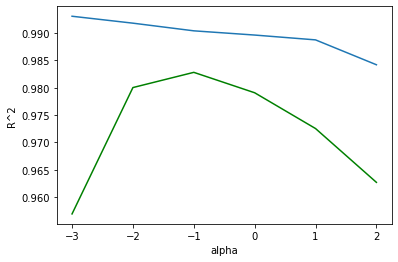

In [23]:
# 적절한 alpha값을 0.001에서 100까지 10배씩 늘려가며 릿지 회귀 모델을 훈련한 다음, 훈련 세트와 테스트 세트의 점수를 파이썬 리스트에 저장한다.
import matplotlib.pyplot as plt

train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
  ridge = Ridge(alpha=alpha)
  ridge.fit(train_scaled, train_target)
  train_score.append(ridge.score(train_scaled, train_target))
  test_score.append(ridge.score(test_scaled, test_target))

# alpha값을 0.001부터 10배씩 늘렸기 때문에 이대로 그래프를 그리면 그래프 왼쪽이 너무 촘촘해진다.
# alpha_list에 있는 6개의 값을 동일한 간격으로 나타내기 위해 로그 함수로 바꾸어 지수로 표현해본다.

plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score, color = 'g')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

아래 초록색 그래프가 테스트 세트 그래프, 위 파란색 그래프가 훈련 세트 그래프이다.

그래프 왼쪽을 보면 훈련세트의 점수가 테스트 세트에 비해 월등히 높아 오버피팅을 의심해볼 수 있고, 오른쪽은 훈련/테스트 세트의 점수가 모두 낮아지는 경향이 있어 이는 언더피팅으로 가는 모습이다.

적절한 alpha값은 두 그래프가 가장 가깝고 테스트 세트의 점수가 가장 높은 -1, 즉 0.1일 때로 보인다.

In [27]:
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

# 디폴트 alpha값 1.0보다 0.1일 때 더 성능이 우수함을 알 수 있다.
# 훈련 세트와 테스트 세트의 점수가 비슷하게 모두 높고, 과대/과소 적합 사이에서 균형을 맞추고 있다.

# 위에서 확인한 alpha=1.0일 때 성능
# 릿지 회귀 (훈련 세트로 평가):  0.9896101671037343
# 릿지 회귀 (테스트 세트로 평가):  0.9790693977615398

0.9903815817570366
0.9827976465386927


# 라쏘 회귀

라쏘 모델을 훈련하는 것은 릿지와 매우 유사하다. Ridge 클래스를 Lasso클래스로 바꾸는 것이 전부다.

In [31]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(train_scaled, train_target)
print("라쏘 모델 성능(훈련 세트)", lasso.score(train_scaled, train_target))
print("라쏘 모델 성능(테스트 세트)", lasso.score(test_scaled, test_target))

train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
  lasso = Lasso(alpha = alpha, max_iter=10000)
  lasso.fit(train_scaled, train_target)
  train_score.append(lasso.score(train_scaled, train_target))
  test_score.append(lasso.score(test_scaled, test_target))

라쏘 모델 성능(훈련 세트) 0.9897898972080961
라쏘 모델 성능(테스트 세트) 0.9800593698421883


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18778.697957792876, tolerance: 518.2793833333334
  positive)
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12972.821345404844, tolerance: 518.2793833333334
  positive)


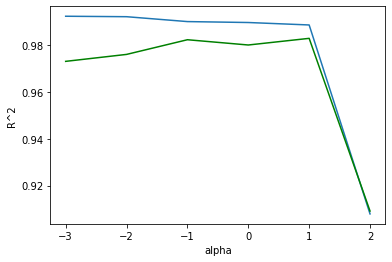

In [33]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score, color='g')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

위 그래프도 파란색(훈련 세트)이 초록색보다 월등히 높은 왼쪽은 오버피팅이 일어난 것을 알 수 있고, alpha=1.0 기준으로 오른쪽으로 갈수록 (alpha가 커질수록) 회귀모델의 성능이 저하되는 언더피팅을 확인할 수 있다.

alpha=1.0으로 다시 훈련해보자.

In [34]:
lasso = Lasso(alpha=1.0)
lasso.fit(train_scaled, train_target)
print("lasso 훈련 세트 성능 (alpha=1.0): ", lasso.score(train_scaled, train_target))
print("lasso 테스트 세트 성능 (alpha=1.0): ", lasso.score(test_scaled, test_target))

lasso 훈련 세트 성능 (alpha=1.0):  0.9897898972080961
lasso 테스트 세트 성능 (alpha=1.0):  0.9800593698421883


In [35]:
# 라쏘 모델은 계수 값을 아예 0으로 만들 수 있다. 라쏘 모델의 계수는 coef_ 속성에 저장되어 있으며, 이중 0인것만 헤아려 보자.

print(np.sum(lasso.coef_ == 0))

# np.sum() 함수는 배열을 모두 더한 값을 변환한다. 넘파이 배열에 비교 연산자를 사용했을 때 각 원소는 True 또는 False가 된다.
# lasso.coef_에 대한 비교연산자로 원소 개수를 헤아리는 효과임.

42


즉, 55개로 늘린 정규화->규제를 거친 특성들에 대한 계수 중 42개가 0이 되어버렸다. 즉, 55개의 특성을 모델에 주입했지만, 라쏘 모델이 사용한 특성은 13개밖에 되지 않았다. 

이런 특징 때문에 라쏘 모델을 유용한 특성을 골라내는 용도로도 사용할 수 있다.

# 키워드로 끝내는 핵심 포인트

> 다중 회귀 (multinomial regression)

여러개의 특성을 사용하는 회귀 모델. 특성이 많으면 선형 모델은 강력한 성능을 발휘한다.

> 특성 공학

주어진 특성을 '조합'하여 새로운 특성을 만드는 일련의 작업 과정

> 릿지

규제 (Regularization) 가 있는 선형 회귀 모델 중 하나이며, 선형 모델의 계수를 작게 만들어 오버피팅을 완화시킨다. 릿지는 비교적 효과가 좋아 널리 사용되는 규제 방법이다.

> 라쏘

또 다른 규제가 있는 선형 회귀 모델이다. 릿지와 달리 계수 값을 아예 0으로 만들 수 도 있다.

> 하이퍼파라미터

머신러닝 알고리즘이 학습하지 않는 파라미터이다. 사람이 사전에 지정하고 모델이 학습할 때 참고하는 값이며, 대표적으로 릿지와 라쏘의 규제 강도 파라미터인 alpha 파라미터가 있다.

# 핵심 패키지와 함수

# pandas

> read_csv()

CSV파일을 읽어서 판다스 데이터프레임 자료구조로 변환하는 함수. 이 함수는 매우 많은 매개변수를 제공하고, 그중에 자주 사용하는 매개변수는 
```
sep : CSV 파일의 구분자를 지정한다. 디폴트는 , (콤마) 이다.
header : 데이터프레임의 열 이름으로 사용할 CSV 파일의 행 번호를 지정. 기본적으로 첫 번째 행을 열 이름으로 사용
skiprows : 파일에서 읽기 전에 건너뛸 행의 갯수를 지정한다.
nrows : 파일에서 읽을 행의 개수를 지정한다.
```

# scikit-learn

> PolynomialFeatures

주어진 특성을 조합하여 새로운 특성을 만든다. (target데이터 넣지 않음) degree는 최고 차수를 지정하며 기본값은 2이다. interaction_only가 True면 거듭제곱 항은 제외되고 특성 간의 곱셈 항만 추가된다. 기본값은 False다. include_bias가 False면 절편을 위한 특성을 추가하지 않고, 기본값은 True이다.

> Ridge

규제가 있는 회귀 알고리즘인 릿지 회귀 모델을 훈련할 때 사용하는 클래스. alpha 매개변수로 규제의 강도를 조정한다. alpha가 커질수록 규제가 세지고 (일반적이게 변하고) 기본 값은 1.0이다. 

solver 매개변수에 최적의 모델을 찾기 위한 방법을 저장할 수 있다. 기본값을 'auto'이며, 데이터에 따라 자동으로 선택된다. 사이킷런 0.17버전에 추가된 sag는 확률론적 평균 경사 하강법 알고리즘으로 특성과 샘플 수가 많을 때 성능이 빠르고 좋다. 싸이킷런 0.19 버전에는 sag의 개선 버전인 saga가 추가되었다. random_state는 solver가 sag나 saga일 때 넘파이 난수 시드값을 지정할 수 있다.

> Lasso

규제가 있는 회귀 알고리즘인 라쏘 회귀 모델을 훈련한다. 이 클래스는 최적의 모델을 찾기 위해 좌표축을 따라 최적화를 수행해나가는 좌표 하강법 (coordinate descent)을 사용한다. alpha와 random_state는 Ridge 클래스와 동일하고, max_iter는 알고리즘의 수행 반복 횟수를 지정한다. 기본값이 1000이다.